In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
class SelfAttention(nn.Module):
    def __init__(self,d_x):
        super().__init__()

        self.d_x=d_x
        self.scale= torch.sqrt(torch.tensor(self.d_x))

        self.q=nn.Linear(d_x,d_x)
        self.k=nn.Linear(d_x,d_x)
        self.v=nn.Linear(d_x,d_x)
    
    def forward(self,x,mask=None):
        Q,K,V=self.q(x),self.k(x),self.v(x)

        attn_score=torch.matmul(Q,K.transpose(-2,-1))/self.scale
        if mask is not None:
            mask=mask.unsqueeze(1)
            attn_score=attn_score.masked_fill(mask==0,float('-inf'))
        weights=F.softmax(attn_score,dim=-1)
        context=torch.matmul(weights,V)
        return context,weights



In [6]:
batch, seq, d = 2, 5, 8
x = torch.randn(batch, seq, d)
mask = torch.ones(batch, seq)
mask[:, -2:] = 0  # Mask out last 2 positions

attn = SelfAttention(d)
context, weights = attn(x, mask)

# Verify: masked positions should have ~0 attention weights
print(weights[:, :, -2:].sum(dim=-1))  # Should be ≈0
print(weights)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], grad_fn=<SumBackward1>)
tensor([[[0.3009, 0.3084, 0.3908, 0.0000, 0.0000],
         [0.3516, 0.3530, 0.2953, 0.0000, 0.0000],
         [0.3122, 0.3828, 0.3050, 0.0000, 0.0000],
         [0.3708, 0.3972, 0.2321, 0.0000, 0.0000],
         [0.3191, 0.3228, 0.3582, 0.0000, 0.0000]],

        [[0.2650, 0.5146, 0.2205, 0.0000, 0.0000],
         [0.2678, 0.4079, 0.3243, 0.0000, 0.0000],
         [0.3348, 0.2739, 0.3913, 0.0000, 0.0000],
         [0.2049, 0.5241, 0.2710, 0.0000, 0.0000],
         [0.3005, 0.2581, 0.4414, 0.0000, 0.0000]]],
       grad_fn=<SoftmaxBackward0>)


In [12]:
import logging
from typing import Tuple

# Configure logging to capture tensor shapes and execution flow
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def test_attention_layer():
    """
    Tests the ScaledDotProductAttention layer for shape correctness 
    and softmax normalization.
    """
    # Hyperparameters
    batch_size = 2
    seq_len = 5
    embed_dim = 16
    
    try:
        # 1. Initialize the layer
        # Assuming the class 'ScaledDotProductAttention' is defined above
        attn_layer = SelfAttention(embed_dim)
        
        # 2. Create dummy input (e.g., a batch of 2 SMS messages, 5 words each)
        dummy_input = torch.randn(batch_size, seq_len, embed_dim)
        logger.info(f"Input shape: {dummy_input.shape}")

        # 3. Forward pass
        context, weights = attn_layer(dummy_input)
        
        # 4. Validation: Shape Checks
        assert context.shape == (batch_size, seq_len, embed_dim), \
            f"Context shape mismatch: {context.shape}"
        assert weights.shape == (batch_size, seq_len, seq_len), \
            f"Weights shape mismatch: {weights.shape}"
        
        # 5. Validation: Softmax Property
        # Summing across the last dimension should equal 1.0 (within epsilon)
        weight_sums = weights.sum(dim=-1)
        expected_sums = torch.ones(batch_size, seq_len)
        
        if torch.allclose(weight_sums, expected_sums, atol=1e-6):
            logger.info("Softmax normalization check: PASSED (Rows sum to 1.0)")
        else:
            logger.error(f"Softmax normalization check: FAILED. Sums: {weight_sums}")

        logger.info("All shape and logic tests passed successfully.")
        
        # Display sample weight matrix for the first batch
        print("\nSample Attention Weight Matrix (First Batch):")
        print(weights[0].detach().numpy())

    except Exception as e:
        logger.error(f"An error occurred during testing: {e}", exc_info=True)

In [23]:
test_attention_layer()


Sample Attention Weight Matrix (First Batch):
[[0.10957181 0.28477177 0.29089415 0.1431896  0.17157264]
 [0.26041427 0.15572244 0.19416584 0.14871012 0.24098736]
 [0.19430603 0.14538008 0.15984778 0.29980215 0.200664  ]
 [0.21390222 0.2444151  0.14002381 0.1842807  0.21737821]
 [0.159253   0.16310185 0.23643419 0.18936941 0.25184152]]


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

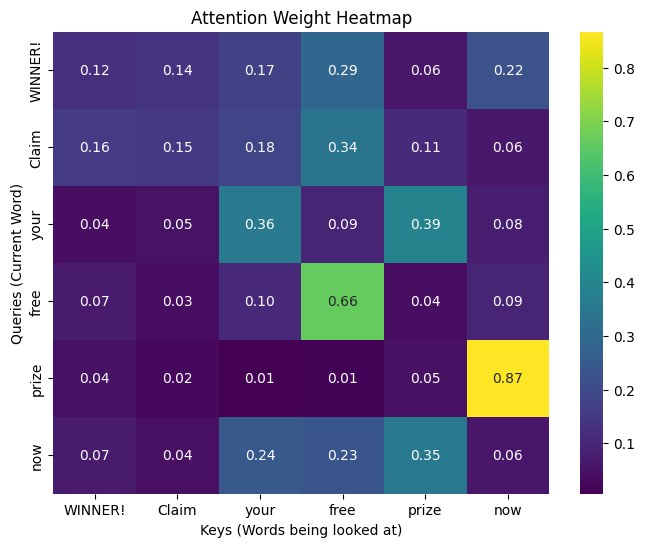

In [17]:
def visualize_attention(weights: torch.Tensor, tokens: list):
    """
    Plots a heatmap of attention weights.
    
    Args:
        weights: Attention weight matrix of shape (seq_len, seq_len)
        tokens: List of strings (words) in the sentence for labeling axes
    """
    try:
        # Convert tensor to numpy for plotting
        attn_matrix = weights.detach().cpu().numpy()

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            attn_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='viridis',
            xticklabels=tokens, 
            yticklabels=tokens
        )
        
        plt.title("Attention Weight Heatmap")
        plt.xlabel("Keys (Words being looked at)")
        plt.ylabel("Queries (Current Word)")
        plt.show()
        
    except Exception as e:
        logger.error(f"Failed to render heatmap: {e}")

# --- Testing with a Spam Example ---
# Mocking tokens from an SMS spam message
sample_sms = "WINNER! Claim your free prize now"
tokens = sample_sms.split()
seq_len = len(tokens)

# Simulating weights from our SimpleAttention layer (Batch 0)
# Normally these would come from: _, weights = attn_layer(dummy_input)
mock_weights = torch.softmax(torch.randn(seq_len, seq_len), dim=-1)

visualize_attention(mock_weights, tokens)